Importing Requisite Libraries

In [91]:
from numpy import ceil
import numpy as np
import pandas as pd
from matplotlib import pyplot as plot
import seaborn as sns

In [92]:
# Importing dataset into pandas DataFrame
df = pd.read_csv(r'd:\ML\1 - EDA Titanic dataset\dataset.csv')

Data Cleaning

In [93]:
def clean_data(df):
    # 1. Replacing all non-integer values in #Age with ceil() of the respective values
    df.loc[(df['Age'] % 1 != 0) & (df['Age'].notna()), 'Age'] = df.loc[(df['Age'] % 1 != 0) & (df['Age'].notna()), 'Age'].apply(ceil)

    # 2. Fill missing values in #Age with random integers between 20-24
    df['Age'] = df['Age'].apply(lambda x: np.random.randint(20, 25) if np.isnan(x) else x)

    # 3. Dropping #Cabin
    df = df.drop(columns=['Cabin'])
    
    # 4. Filling a missing value in #Fare with a random integer between 1-30
    df['Fare'] = df['Fare'].apply(lambda x: np.random.randint(1, 31) if pd.isna(x) else x)
    return df

df = clean_data(df.copy())
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,892,0,3,"Kelly, Mr. James",male,35.0,0,0,330911,7.8292,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,0,3,"Spector, Mr. Woolf",male,22.0,0,0,A.5. 3236,8.0500,S
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C
415,1307,0,3,"Saether, Mr. Simon Sivertsen",male,39.0,0,0,SOTON/O.Q. 3101262,7.2500,S
416,1308,0,3,"Ware, Mr. Frederick",male,24.0,0,0,359309,8.0500,S


In [94]:
# #Embarked - Port where the passengers boarded the ship : [C = Cherbourg Q = Queenstown S = Southampton]
embarkedList = ['Queenstown', 'Southampton', 'Cherbourg']

In [95]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          418 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         418 non-null    float64
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 36.1+ KB


In [96]:
# List of columns to check if they provide meaning to the survival of passengers
cols = ['Pclass', 'Sex', 'Age', 'SibSp', 'Embarked']

Visulaizing the Data

In [97]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,892,0,3,"Kelly, Mr. James",male,35.0,0,0,330911,7.8292,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,0,3,"Spector, Mr. Woolf",male,22.0,0,0,A.5. 3236,8.0500,S
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C
415,1307,0,3,"Saether, Mr. Simon Sivertsen",male,39.0,0,0,SOTON/O.Q. 3101262,7.2500,S
416,1308,0,3,"Ware, Mr. Frederick",male,24.0,0,0,359309,8.0500,S


In [98]:
tempDf = df['Pclass']
PclassBarPlotX = tempDf.unique().tolist()
PclassTotalBarPlotY = tempDf.value_counts().tolist()
PclassSurvivedBarPlotY = [len(df[(df['Pclass']==i) & (df['Survived']==1)]) for i in PclassBarPlotX]

Text(0.5, 1.0, "Distribution of Passengers' class")

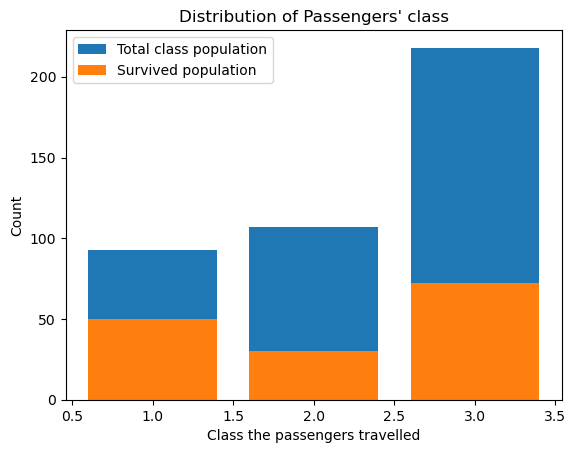

In [99]:
plot.bar(PclassBarPlotX, PclassTotalBarPlotY)
plot.bar(PclassBarPlotX, PclassSurvivedBarPlotY)
plot.xlabel('Class the passengers travelled')
plot.ylabel('Count')
plot.legend(['Total class population', 'Survived population'])
plot.title("Distribution of Passengers' class")

In [100]:
plot.close()

In [101]:
length = len(PclassBarPlotX)
PclassSurvivedPercentage = dict()
for i in range(length):
    classpop = PclassTotalBarPlotY[i]
    survivedpop = PclassSurvivedBarPlotY[i]
    survivedpercentage = (survivedpop/classpop)*100
    PclassSurvivedPercentage[PclassBarPlotX[i]] = survivedpercentage
PClassSurvivedPercentageDF = pd.DataFrame(list(PclassSurvivedPercentage.items()), columns=['Pclass', 'SurvivedPercentage'])

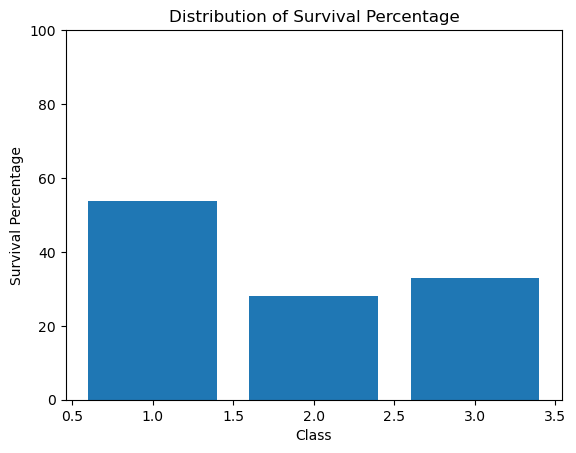

In [102]:
plot.bar(PclassSurvivedPercentage.keys(), PclassSurvivedPercentage.values())
plot.ylim(0, 100)
plot.title('Distribution of Survival Percentage')
plot.xlabel('Class')
plot.ylabel('Survival Percentage')
plot.show()

In [103]:
tempDf = df['Sex'].value_counts()
SexBarPlotX = df['Sex'].unique()
SexTotalBarPlotY = tempDf.tolist()
SexSurvivedBarPlotY = [len(df[(df['Sex']==SexBarPlotX[i]) & (df['Survived']==1)]) for i in range(len(SexBarPlotX))]

Text(0, 0.5, 'Count')

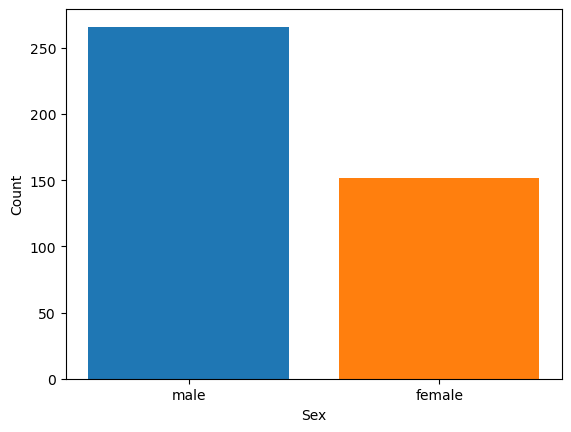

In [104]:
plot.bar(SexBarPlotX, SexTotalBarPlotY)
plot.bar(SexBarPlotX, SexSurvivedBarPlotY)
plot.xlabel("Sex")
plot.ylabel("Count")

In [105]:
plot.close()

In [106]:
df[(df['Sex']=='female')&(df['Survived']==1)]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,S
6,898,1,3,"Connolly, Miss. Kate",female,30.0,0,0,330972,7.6292,Q
8,900,1,3,"Abrahim, Mrs. Joseph (Sophie Halaut Easu)",female,18.0,0,0,2657,7.2292,C
12,904,1,1,"Snyder, Mrs. John Pillsbury (Nelle Stevenson)",female,23.0,1,0,21228,82.2667,S
...,...,...,...,...,...,...,...,...,...,...,...
409,1301,1,3,"Peacock, Miss. Treasteall",female,3.0,1,1,SOTON/O.Q. 3101315,13.7750,S
410,1302,1,3,"Naughton, Miss. Hannah",female,24.0,0,0,365237,7.7500,Q
411,1303,1,1,"Minahan, Mrs. William Edward (Lillian E Thorpe)",female,37.0,1,0,19928,90.0000,Q
412,1304,1,3,"Henriksson, Miss. Jenny Lovisa",female,28.0,0,0,347086,7.7750,S


In [107]:
length = len(SexBarPlotX)
SexSurvivedPercentage = dict()
for i in range(length):
    sexpop = SexTotalBarPlotY[i]
    survivedpop = SexSurvivedBarPlotY[i]
    survivedpercentage = (survivedpop/sexpop)*100
    SexSurvivedPercentage[SexBarPlotX[i]] = survivedpercentage
SexSurvivedPercentageDF = pd.DataFrame(list(SexSurvivedPercentage.items()), columns=['Sex', 'SurvivedPercentage'])
SexSurvivedPercentageDF

,Sex,SurvivedPercentage
0,male,0.0
1,female,100.0


In [108]:
age_bins = np.arange(0, df['Age'].max() + 10, 10)
AgeBarPlotX = [f'{int(age_bins[i])}-{int(age_bins[i+1]-1)}' for i in range(len(age_bins)-1)]
AgeTotalBarPlotY = df.groupby(pd.cut(df['Age'], age_bins, right=False)).size().tolist()
AgeSurvivedBarPlotY = df[df['Survived'] == 1].groupby(pd.cut(df['Age'], age_bins, right=False)).size().tolist()

C:\Users\tsdha\AppData\Local\Temp\ipykernel_32048\3638842719.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  AgeTotalBarPlotY = df.groupby(pd.cut(df['Age'], age_bins, right=False)).size().tolist()
C:\Users\tsdha\AppData\Local\Temp\ipykernel_32048\3638842719.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  AgeSurvivedBarPlotY = df[df['Survived'] == 1].groupby(pd.cut(df['Age'], age_bins, right=False)).size().tolist()


In [109]:
plot.close()

In [110]:
plot.close()

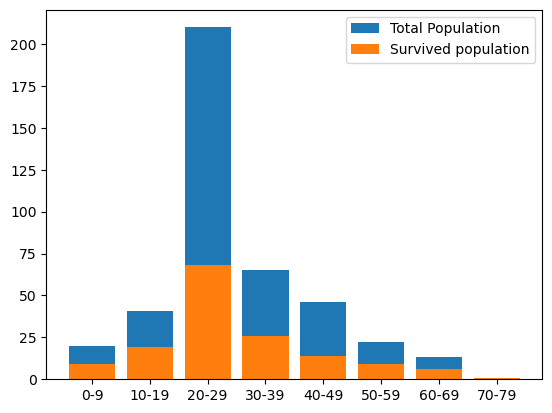

In [111]:
plot.bar(AgeBarPlotX, AgeTotalBarPlotY)
plot.bar(AgeBarPlotX, AgeSurvivedBarPlotY)
plot.legend(['Total Population', 'Survived population'])

In [112]:
plot.close()

In [113]:
AgeSurvivedPercentage = dict()
length = len(AgeBarPlotX)
for i in range(length):
    totalpop = AgeTotalBarPlotY[i]
    survivedpop = AgeSurvivedBarPlotY[i]
    survivedpercentage = (survivedpop/totalpop) * 100
    AgeSurvivedPercentage[AgeBarPlotX[i]] = survivedpercentage
AgeSurvivedPercentageDf = pd.DataFrame(list(AgeSurvivedPercentage.items()), columns=['Age', 'Survived Percentage'])
AgeSurvivedPercentageDf

,Age,Survived Percentage
0,0-9,45.000000
1,10-19,46.341463
2,20-29,32.380952
3,30-39,40.000000
4,40-49,30.434783
5,50-59,40.909091
6,60-69,46.153846
7,70-79,100.000000


In [114]:
SibSpBarPlotX = df['SibSp'].unique()
SibSpBarPlotY = df['SibSp'].value_counts().tolist()

length = len(SibSpBarPlotX)
SibSpSurvivedBarPlotY = [ len(df[ (df['SibSp']==SibSpBarPlotX[i]) & ( df['Survived']==1 ) ]) for i in range(length) ]

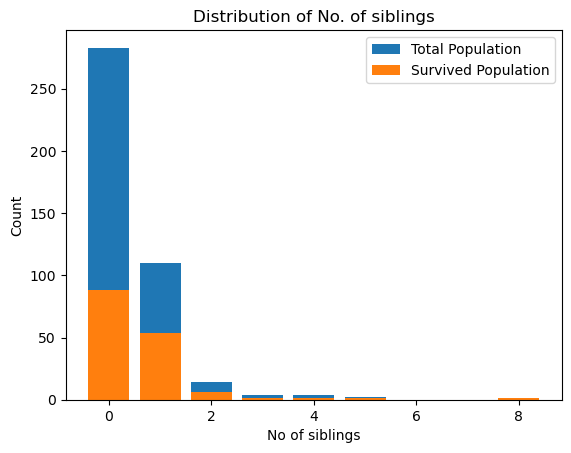

In [115]:
plot.bar(SibSpBarPlotX, SibSpBarPlotY)
plot.bar(SibSpBarPlotX, SibSpSurvivedBarPlotY)
plot.title("Distribution of No. of siblings")
plot.xlabel('No of siblings')
plot.ylabel('Count')
plot.legend(['Total Population', 'Survived Population'])
plot.show()

In [116]:
plot.close()

In [117]:
SibSpSurvivedPercentage = dict()
for i in range(length):
    totalpop = SibSpBarPlotY[i]
    survivedpop = SibSpSurvivedBarPlotY[i]
    survivedPercentage = (survivedpop/totalpop) * 100
    SibSpSurvivedPercentage[SibSpBarPlotX[i]] = survivedPercentage
SibSpSurvivedPercentageDf = pd.DataFrame(list(SibSpSurvivedPercentage.items()), columns=['No of siblings', 'Survived Percentage'])
SibSpSurvivedPercentageDf

,No of siblings,Survived Percentage
0,0,31.095406
1,1,49.090909
2,2,42.857143
3,3,25.000000
4,4,25.000000
5,5,50.000000
6,8,100.000000


In [118]:
tempDf = df['Embarked']
embarkedBarPlotX = tempDf.unique()
length = len(embarkedBarPlotX)
embarkedTotalBarPlotY = tempDf.value_counts()
embarkedSurvivedBarPlotY = [ len( df[(tempDf == embarkedBarPlotX[i]) & (df['Survived'] == 1 )]) for i in range(length)]
embarkedBarPlotX = [embarkedList[i] for i in range(length)]

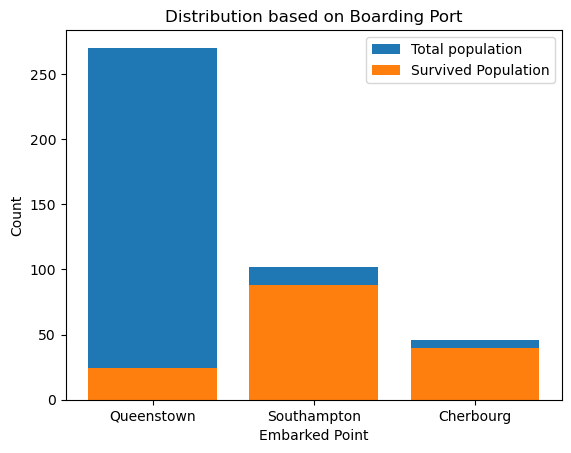

In [119]:
plot.bar(embarkedBarPlotX, embarkedTotalBarPlotY)
plot.bar(embarkedBarPlotX, embarkedSurvivedBarPlotY)
plot.title('Distribution based on Boarding Port')
plot.xlabel('Embarked Point')
plot.ylabel('Count')
plot.legend(['Total population', 'Survived Population'])
plot.show()

In [120]:
plot.close()

Feature vs Feature Analysis

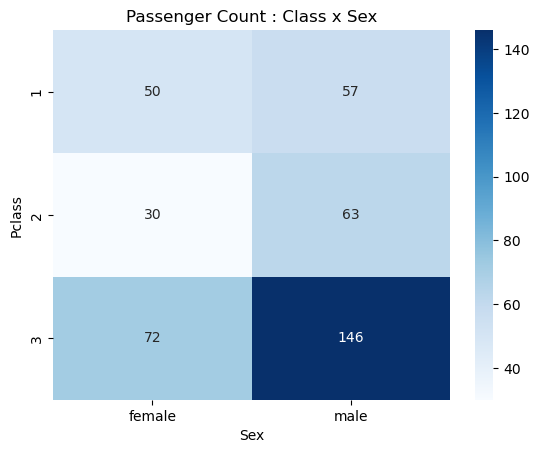

In [121]:
#CrossTab Heatmap
crossTab = pd.crosstab(df['Pclass'], df['Sex'])
sns.heatmap(crossTab, annot=True, cmap='Blues', fmt='d')
plot.title('Passenger Count : Class x Sex')
plot.show()

In [122]:
plot.close()

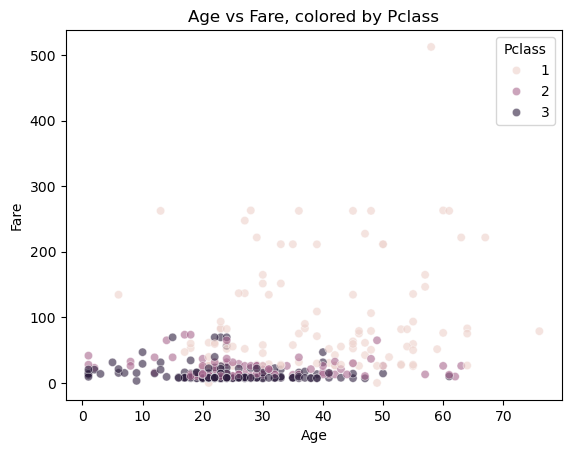

In [123]:
# C2. Age vs Fare — scatter
sns.scatterplot(data=df, x='Age', y='Fare', hue='Pclass', alpha=0.6)
plot.title('Age vs Fare, colored by Pclass')
plot.show()

In [124]:
plot.close()

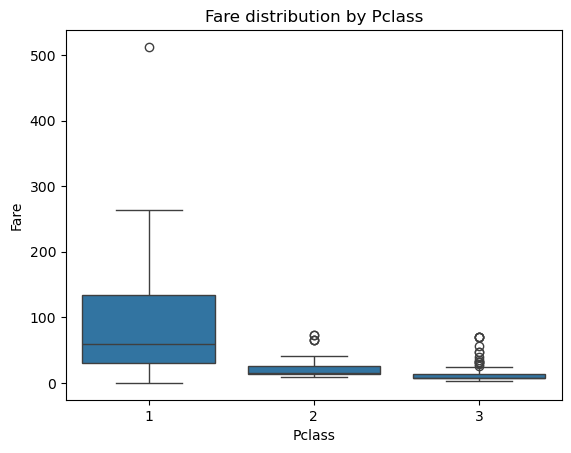

In [125]:
# C3. Pclass vs Fare — are they redundant?
sns.boxplot(data=df, x='Pclass', y='Fare')
plot.title('Fare distribution by Pclass')
plot.show()
# Yes — strong overlap. Pclass and Fare carry similar information.
# You may not need both in a model.

In [126]:
plot.close()

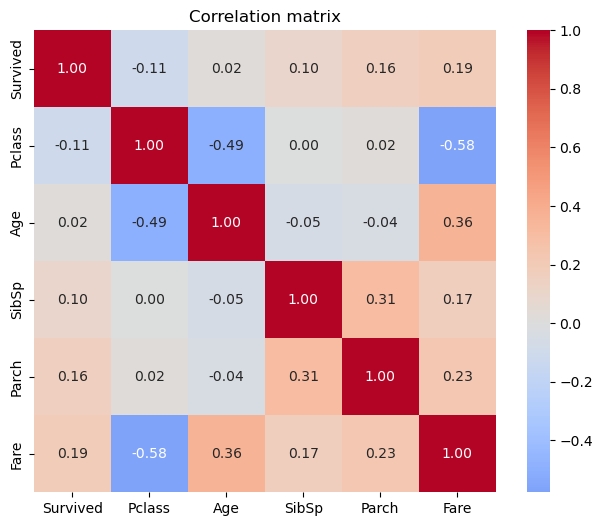

In [127]:
# C4 & C5. Correlation matrix — all numeric columns
corr = df[['Survived','Pclass','Age','SibSp','Parch','Fare']].corr()

plot.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plot.title('Correlation matrix')
plot.show()

In [128]:
plot.close()

CONCLUSION

In [129]:
# =============================================================================
# CONCLUSION — Titanic EDA Summary
# =============================================================================

# WHAT WE FOUND:
# --------------
# 1. SEX is the strongest predictor — women survived at 74%, men at only 19%.
#    → Encode as binary: female=1, male=0

# 2. PCLASS is second strongest — 1st class had 2.5x survival rate of 3rd class.
#    → Keep as ordinal (1, 2, 3) or one-hot encode

# 3. FARE correlates heavily with Pclass — carries similar signal.

# 4. AGE matters at the extremes — children (<10) survived more,
#    elderly men survived least.
#    → Impute missing values using median-by-Pclass grouping

# 5. SIBSP + PARCH individually are weak, but together as FamilySize they're strong.
#    → Engineer: FamilySize = SibSp + Parch + 1
#    → Solo travelers (FamilySize=1) and very large families (>4) fared worse

# 6. EMBARKED appears predictive alone, but signal disappears when Pclass is controlled.
#    → C had more 1st class passengers — it's a proxy, not a real signal
#    → Still keep it (one-hot encoded) as it adds minor signal

# 7. SEX × PCLASS interaction is the single biggest combined insight.
#    → Consider adding an interaction feature: Sex_Pclass

# FEATURES DROPPED:
# -----------------
# - PassengerId : just an index, no signal
# - Name        : free text; title extraction already done if needed
# - Ticket      : high cardinality, no clean signal
# - Cabin       : ~77% missing; deck letter extraction optional but dropped here
# - Fare        : Heavily correlates with Pclass
# - PArch       : Heavily correlates with SibSp
# - Embarked    : Provides no signal


# =============================================================================

Dropping Unnecessary features from DataFrame

In [130]:
columnsToDrop = ['PassengerId', 'Name', 'Parch', 'Ticket', 'Fare', 'Embarked']
df = df.drop(columns=columnsToDrop)
insert_loc = df.columns.get_loc('Sex')
df = pd.concat([df.iloc[:,:insert_loc], pd.get_dummies(df.loc[:, ['Sex']]), df.iloc[:,insert_loc+1:]], axis=1)
df.drop('Sex_male', axis=1, inplace=True)

Final Cleaned DataFrame

In [131]:
df

,Survived,Pclass,Sex_female,Age,SibSp
0,0,3,False,35.0,0
1,1,3,True,47.0,1
2,0,2,False,62.0,0
3,0,3,False,27.0,0
4,1,3,True,22.0,1
...,...,...,...,...,...
413,0,3,False,22.0,0
414,1,1,True,39.0,0
415,0,3,False,39.0,0
416,0,3,False,24.0,0
